In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as open

print("Environment working successfully")

Environment working successfully


In [48]:
df = pd.read_excel("Consumer_Complaints.xlsx")

In [49]:
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [50]:
df.shape

(62516, 12)

In [51]:
df.columns

Index(['Complaint ID', 'Submitted via', 'Date submitted', 'Date received',
       'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company response to consumer',
       'Timely response?'],
      dtype='str')

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  str           
 2   Date submitted                62516 non-null  datetime64[us]
 3   Date received                 62516 non-null  datetime64[us]
 4   State                         62516 non-null  str           
 5   Product                       62516 non-null  str           
 6   Sub-product                   62509 non-null  str           
 7   Issue                         62516 non-null  str           
 8   Sub-issue                     51658 non-null  str           
 9   Company public response       60341 non-null  str           
 10  Company response to consumer  62516 non-null  str           
 11  Timely response?              61022 non

In [53]:
df.isnull().sum().sort_values(ascending=False)

Sub-issue                       10858
Company public response          2175
Timely response?                 1494
Sub-product                         7
Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Issue                               0
Company response to consumer        0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(0)

# Describe is used to give quick statistical overview of every datatype in the dataset 

In [55]:
df.describe(include='all')

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
count,6.251600e+04,62516,62516,62516,62516,62516,62509,62516,51658,60341,62516,61022
unique,NaN,7,NaN,NaN,51,9,46,76,158,6,5,2
top,NaN,Web,NaN,NaN,CA,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Company has responded to the consumer and the ...,Closed with explanation,Yes
freq,NaN,45423,NaN,NaN,13709,24814,20768,15109,5596,60311,41044,58619
mean,4.512642e+06,NaN,2020-11-24 16:07:14.883869,2020-11-25 21:31:05.071341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.471340e+06,NaN,2017-05-01 00:00:00,2017-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.254020e+06,NaN,2019-05-22 00:00:00,2019-05-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.178582e+06,NaN,2021-03-02 00:00:00,2021-03-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,5.771284e+06,NaN,2022-07-14 00:00:00,2022-07-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,7.458912e+06,NaN,2023-08-28 00:00:00,2023-08-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# stripping eliminates extra spaces before and after text
# lower converts all names into lowercase
# replace is used to convert extra space into underscore for better readibility

In [56]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

# converting all dates into a standardised date time format

In [57]:
df['date_submitted'] = pd.to_datetime(df['date_submitted'])
df['date_received'] = pd.to_datetime(df['date_received'])

In [58]:
df['response_days'] = (df['date_received'] - df['date_submitted']).dt.days

In [59]:
df['product'].value_counts().head(10)

product
Checking or savings account                                                     24814
Credit card or prepaid card                                                     16197
Credit reporting, credit repair services, or other personal consumer reports     7710
Mortgage                                                                         6601
Money transfer, virtual currency, or money service                               3453
Debt collection                                                                  2736
Vehicle loan or lease                                                             633
Payday loan, title loan, or personal loan                                         333
Student loan                                                                       39
Name: count, dtype: int64

In [60]:
df['issue'].value_counts().head(10)

issue
Managing an account                                                                 15109
Incorrect information on your report                                                 4931
Problem with a purchase shown on your statement                                      4415
Closing an account                                                                   2953
Trouble during payment process                                                       2827
Opening an account                                                                   2725
Problem with a lender or other company charging your account                         2493
Fraud or scam                                                                        1987
Struggling to pay mortgage                                                           1904
Problem with a credit reporting company's investigation into an existing problem     1876
Name: count, dtype: int64

In [61]:
df['timely_response?'].value_counts()

timely_response?
Yes    58619
No      2403
Name: count, dtype: int64

In [62]:
df['submitted_via'].value_counts()

submitted_via
Web             45423
Referral        10766
Phone            4684
Postal mail      1318
Fax               233
Web Referral       90
Email               2
Name: count, dtype: int64

In [63]:
df['state'].value_counts().head(10)

state
CA    13709
FL     6488
TX     4686
NY     4442
GA     2921
NJ     2664
IL     2270
MA     2141
MD     1959
VA     1731
Name: count, dtype: int64

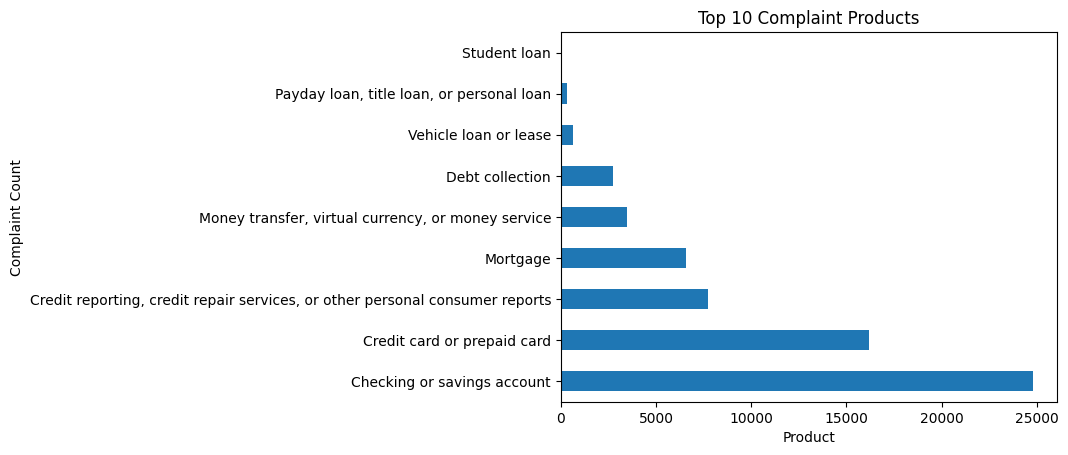

In [64]:
df['product'].value_counts().head(10).plot(kind='barh')

plt.title("Top 10 Complaint Products")
plt.xlabel("Product")
plt.ylabel("Complaint Count")



plt.show()

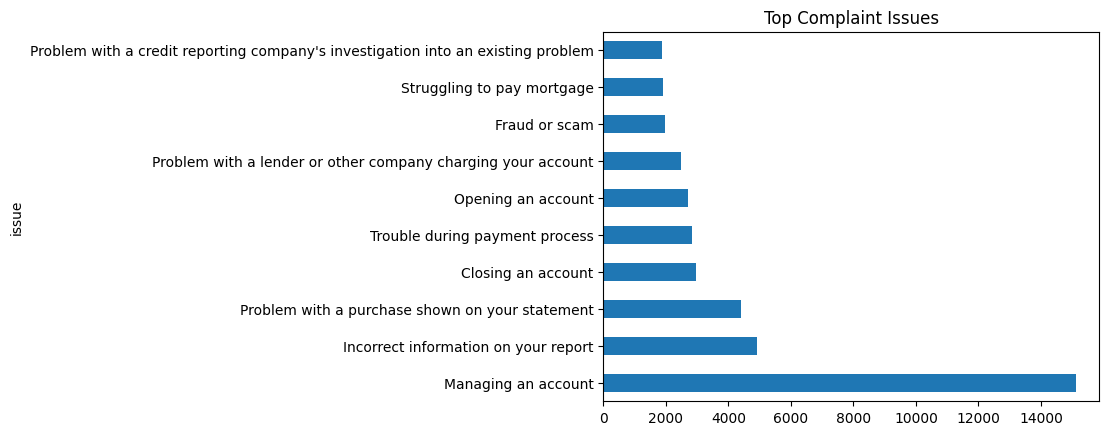

In [65]:
df['issue'].value_counts().head(10).plot(kind='barh')

plt.title("Top Complaint Issues")

plt.show()

In [66]:
df['submitted_via'].unique()

<ArrowStringArray>
['Referral', 'Web', 'Phone', 'Postal mail', 'Web Referral', 'Fax', 'Email']
Length: 7, dtype: str

In [67]:
df['timely_response?'].unique()

<ArrowStringArray>
['Yes', nan, 'No']
Length: 3, dtype: str

In [68]:
df['product'].unique()

<ArrowStringArray>
[                                                                    'Mortgage',
                           'Money transfer, virtual currency, or money service',
 'Credit reporting, credit repair services, or other personal consumer reports',
                                                  'Credit card or prepaid card',
                                                  'Checking or savings account',
                                                        'Vehicle loan or lease',
                                                              'Debt collection',
                                    'Payday loan, title loan, or personal loan',
                                                                 'Student loan']
Length: 9, dtype: str

In [69]:
df['company_response_to_consumer'].unique()

<ArrowStringArray>
[        'Closed with explanation',     'Closed with monetary relief',
                     'In progress', 'Closed with non-monetary relief',
                          'Closed']
Length: 5, dtype: str

In [70]:
text_columns = [
    'submitted_via',
    'state',
    'product',
    'sub-product',
    'issue',
    'sub-issue',
    'company_public_response',
    'company_response_to_consumer',
    'timely_response?'
]

# for every text column, clean the text into a standardized format by stripping and lowercase

In [71]:
for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# handling missing values by replacing missing values 

In [72]:
df['sub-issue'] = df['sub-issue'].fillna('not_specified')

df['company_public_response'] = df['company_public_response'].fillna('no_public_response')

In [73]:
df['submission_year'] = df['date_submitted'].dt.year

df['submission_month'] = df['date_submitted'].dt.month

df['submission_day'] = df['date_submitted'].dt.day_name()

# response days field is created 

In [74]:
df['response_days'] = (
    df['date_received'] - df['date_submitted']
).dt.days

In [75]:
df['response_days'].describe()

count    62516.000000
mean         1.224886
std          5.649298
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: response_days, dtype: float64

# response days greater than 7 are flagged as delayed response

In [76]:
df['delayed_response_flag'] = np.where(
    df['response_days'] > 7,
    1,
    0
)

In [77]:
df['delayed_response_flag'].value_counts()

delayed_response_flag
0    60073
1     2443
Name: count, dtype: int64

In [78]:
df['product'].value_counts().head(10)

product
checking or savings account                                                     24814
credit card or prepaid card                                                     16197
credit reporting, credit repair services, or other personal consumer reports     7710
mortgage                                                                         6601
money transfer, virtual currency, or money service                               3453
debt collection                                                                  2736
vehicle loan or lease                                                             633
payday loan, title loan, or personal loan                                         333
student loan                                                                       39
Name: count, dtype: int64

In [79]:
(
    df.groupby('product')['response_days'] 
    .mean() 
    .sort_values(ascending=False)
    .head(10)
)

product
student loan                                                                    2.128205
mortgage                                                                        1.860779
payday loan, title loan, or personal loan                                       1.675676
debt collection                                                                 1.643275
vehicle loan or lease                                                           1.440758
checking or savings account                                                     1.233296
credit card or prepaid card                                                     1.127369
money transfer, virtual currency, or money service                              1.064002
credit reporting, credit repair services, or other personal consumer reports    0.740078
Name: response_days, dtype: float64

In [80]:
df['state'].value_counts().head(10)

state
ca    13709
fl     6488
tx     4686
ny     4442
ga     2921
nj     2664
il     2270
ma     2141
md     1959
va     1731
Name: count, dtype: int64

In [81]:
df.groupby('state')['response_days'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

state
sd    3.088235
ms    2.468085
nh    2.236181
ak    2.036364
me    2.000000
nm    1.721461
ct    1.680036
wi    1.542955
nv    1.532351
ok    1.470990
Name: response_days, dtype: float64

In [82]:
df['submitted_via'].value_counts()

submitted_via
web             45423
referral        10766
phone            4684
postal mail      1318
fax               233
web referral       90
email               2
Name: count, dtype: int64

In [83]:
df.groupby('submitted_via')['response_days'] \
    .mean() \
    .sort_values(ascending=False)

submitted_via
referral        3.297882
phone           1.786507
postal mail     1.272382
web referral    0.977778
web             0.678577
email           0.500000
fax             0.484979
Name: response_days, dtype: float64

In [84]:
df['issue'].value_counts().head(15)

issue
managing an account                                                                 15109
incorrect information on your report                                                 4931
problem with a purchase shown on your statement                                      4415
closing an account                                                                   2953
trouble during payment process                                                       2827
opening an account                                                                   2725
problem with a lender or other company charging your account                         2493
fraud or scam                                                                        1987
struggling to pay mortgage                                                           1904
problem with a credit reporting company's investigation into an existing problem     1876
getting a credit card                                                                1867
othe

In [85]:
df.groupby('issue')['response_days'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

issue
excessive fees                                                   5.000000
struggling to repay your loan                                    4.777778
managing, opening, or closing your mobile wallet account         4.750000
credit limit changed                                             3.125000
advertising                                                      2.785714
getting the loan                                                 2.625000
problem with a company's investigation into an existing issue    2.581081
struggling to pay mortgage                                       2.481092
problem with cash advance                                        2.285714
problem with a purchase or transfer                              2.244080
Name: response_days, dtype: float64

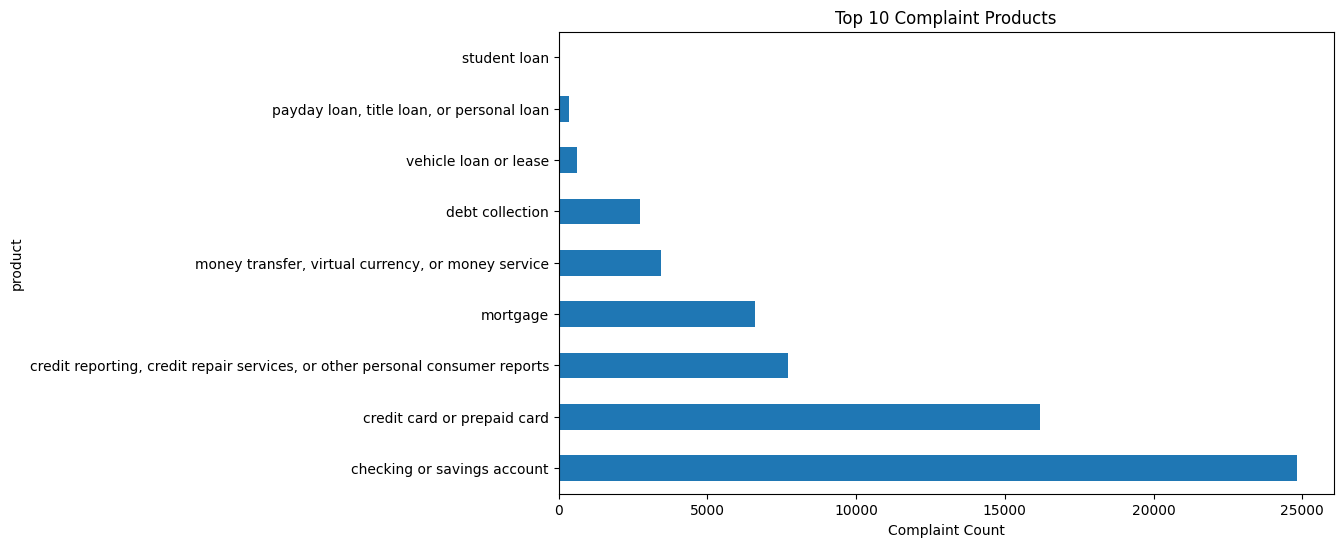

In [86]:
top_products = df['product'].value_counts().head(10)

top_products.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top 10 Complaint Products")
plt.xlabel("Complaint Count")

plt.show()

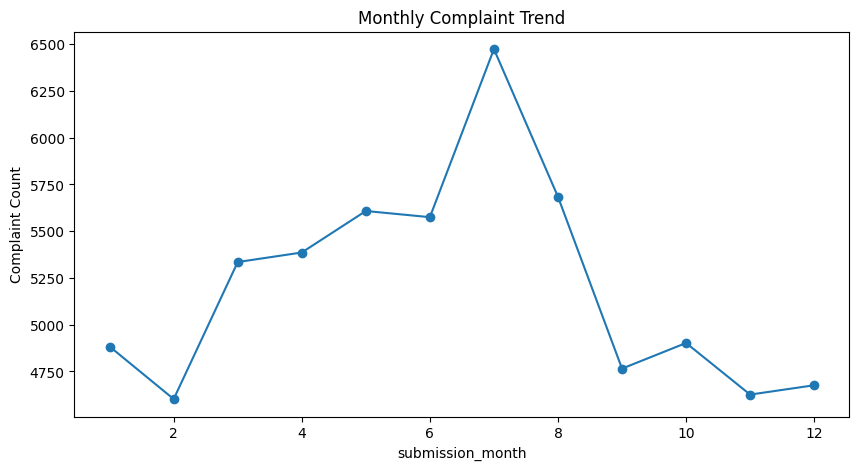

In [87]:
monthly_trend = df.groupby('submission_month').size()

monthly_trend.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Complaint Trend")
plt.ylabel("Complaint Count")

plt.show()

In [88]:
df.to_csv(
    '/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2/cleaned_data.csv',
    index=False
)

In [89]:
import os

os.path.exists('/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2')

True

In [90]:
import os

os.listdir('/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2')

['cleaned_data',
 'eda.ipynb',
 'tempCodeRunnerFile.py',
 'augmented_complaints.csv',
 '.DS_Store',
 'ConsumerComplaints_DataDictionary.csv',
 'tempCodeRunnerFile.ipynb',
 'Consumer_Complaints.xlsx',
 'nlp_analysis.ipynb',
 'cleaned_data.csv',
 'complaint_summary.csv',
 'README.md',
 'dashboard_ready_dataset.csv',
 'app.py']

# Consumer complaint intelligence system built using CFPB-inspired complaint data with synthetic narrative augmentation for NLP experimentation and dashboard simulation.

In [91]:
import random

In [92]:
templates = [

    "I am extremely frustrated with {product}. Facing constant issues regarding {issue}. The main problem was {sub_issue}. Worst experience ever.",

    "Customer reported serious problems in {product}. Complaint was about {issue} and especially {sub_issue}. Very disappointing service.",

    "Honestly very unhappy with the way {product} handled my issue. There were multiple complications regarding {issue} and {sub_issue}.",

    "This issue has been going on for weeks. Problems related to {issue} in {product}. Main concern: {sub_issue}. Totally unacceptable.",

    "The consumer faced repeated trouble regarding {issue} under {product}. Additional issue reported was {sub_issue}.",

    "Terrible experience with {product}. I contacted support many times regarding {issue} but still faced {sub_issue}.",

    "I had a decent experience initially but later problems started with {issue} in {product}. Especially regarding {sub_issue}.",

    "Very poor customer service. Complaint related to {issue} under {product}. The issue involved {sub_issue}.",

    "The whole process was confusing and stressful. Faced issues in {product} regarding {issue}. Also experienced {sub_issue}.",

    "I dont understand why this problem still exists. Complaint regarding {issue} in {product}. Main problem was {sub_issue}.",

    "Customer is highly dissatisfied with {product}. Serious concerns related to {issue} and specifically {sub_issue}.",

    "Worst financial service ever!! Problems with {issue} under {product}. They never resolved {sub_issue}.",

    "The complaint involved {issue} in {product}. Customer also mentioned {sub_issue}. Overall experience was really bad.",

    "Everything was delayed and badly managed. Issue related to {issue} under {product}. Main complaint: {sub_issue}.",

    "I faced unnecessary stress because of {product}. Main issue was {issue} and the company failed to address {sub_issue}.",

    "Not satisfied at all. Problems regarding {issue} in {product}. The situation became worse due to {sub_issue}.",

    "Customer stated that {product} services were very disappointing. Complaint focused on {issue} and {sub_issue}.",

    "Absolutely ridiculous experience. Issue involving {issue} under {product}. Also faced {sub_issue}.",

    "The support team was slow and unhelpful. Main complaint in {product} was {issue}. Additional concern: {sub_issue}.",

    "There was continuous confusion regarding {issue} in {product}. Customer particularly highlighted {sub_issue}."

]

# Synthetic customer complaint narratives were generated using template based text augmentation approach in which structured fields are combined into human readable complaint descriptions

In [93]:
def generate_narrative(row):

    template = random.choice(templates)

    narrative = template.format(
        product=row['product'],
        issue=row['issue'],
        sub_issue=row['sub-issue']
    )

    return narrative

In [94]:
df['complaint_narrative'] = df.apply(
    generate_narrative,
    axis=1
)

In [95]:
df[['product', 'issue', 'sub-issue', 'complaint_narrative']].head()

,product,issue,sub-issue,complaint_narrative
0,mortgage,applying for a mortgage or refinancing an exis...,not_specified,The whole process was confusing and stressful....
1,"money transfer, virtual currency, or money ser...",lost or stolen check,not_specified,Absolutely ridiculous experience. Issue involv...
2,"credit reporting, credit repair services, or o...",incorrect information on your report,account information incorrect,I had a decent experience initially but later ...
3,credit card or prepaid card,problem getting a card or closing an account,"trouble getting, activating, or registering a ...",Customer reported serious problems in credit c...
4,credit card or prepaid card,closing your account,company closed your account,I faced unnecessary stress because of credit c...


In [96]:
df.to_csv(
    '/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2/augmented_complaints.csv',
    index=False
)

# NLP section

In [97]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [98]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/anshikapandey/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anshikapandey/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [99]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/anshikapandey/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Stop words are words like (the,is,are,a,an etc.)

In [100]:
stop_words = set(stopwords.words('english'))

# Text cleaning and NLP preprocessing is done in which complaint narratives were cleaned and standardized before NLP analysis

In [101]:
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    # tokenize words means splitting sentence into individual words into tokens
    tokens = word_tokenize(text)

    # remove stopwords
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # join cleaned words back into sentence
    cleaned_text = ' '.join(filtered_tokens)

    return cleaned_text

In [102]:
df['cleaned_text'] = df['complaint_narrative'].apply(clean_text)

In [103]:
df.columns

Index(['complaint_id', 'submitted_via', 'date_submitted', 'date_received',
       'state', 'product', 'sub-product', 'issue', 'sub-issue',
       'company_public_response', 'company_response_to_consumer',
       'timely_response?', 'response_days', 'submission_year',
       'submission_month', 'submission_day', 'delayed_response_flag',
       'complaint_narrative', 'cleaned_text'],
      dtype='str')

In [104]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("?", "", regex=False)
)

In [105]:
df.columns

Index(['complaint_id', 'submitted_via', 'date_submitted', 'date_received',
       'state', 'product', 'sub_product', 'issue', 'sub_issue',
       'company_public_response', 'company_response_to_consumer',
       'timely_response', 'response_days', 'submission_year',
       'submission_month', 'submission_day', 'delayed_response_flag',
       'complaint_narrative', 'cleaned_text'],
      dtype='str')

In [ ]:
df[['complaint_narrative', 'cleaned_text']].head()

,complaint_narrative,cleaned_text
0,The whole process was confusing and stressful....,thewholeprocesswasconfusingandstressfulfacedis...
1,Absolutely ridiculous experience. Issue involv...,absolutelyridiculousexperienceissueinvolvinglo...
2,I had a decent experience initially but later ...,ihadadecentexperienceinitiallybutlaterproblems...
3,Customer reported serious problems in credit c...,customerreportedseriousproblemsincreditcardorp...
4,I faced unnecessary stress because of credit c...,ifacedunnecessarystressbecauseofcreditcardorpr...


In [110]:
df.to_csv(
    '/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2/cleaned_data.csv',
    index=False
)

## Create TF TDF vectorization(converting text into numerical representation)

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Creates TF IDF model where only top 100 most important words are considered and stop words are removed which improves NLP quality 

In [113]:
tfidf = TfidfVectorizer(
    max_features=100,
    stop_words='english'
)

# Creates TF IDF matrix where 'fit' used to learn what words exist, their frequency and how important they are and 'transform' used to convert cleaned complaint into numerical vectors

In [114]:
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])

# Extracting all the important words selected by TF IDF

In [115]:
feature_names = tfidf.get_feature_names_out()

# Create TF IDF data frame for better readability

In [116]:
tfidf_scores = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

In [117]:
word_importance = tfidf_scores.mean().sort_values(ascending=False)

In [118]:
word_importance.head(20)

account       0.169236
card          0.132603
credit        0.093191
problem       0.087723
savings       0.077960
checking      0.077959
regarding     0.069518
issue         0.067889
complaint     0.065042
customer      0.061107
managing      0.061019
problems      0.058054
main          0.056217
mortgage      0.054649
faced         0.053969
experience    0.052414
prepaid       0.048564
service       0.047335
related       0.046949
company       0.045619
dtype: float64

In [157]:
top_words = word_importance.head(15)

# Visualise top TF IDF keywords

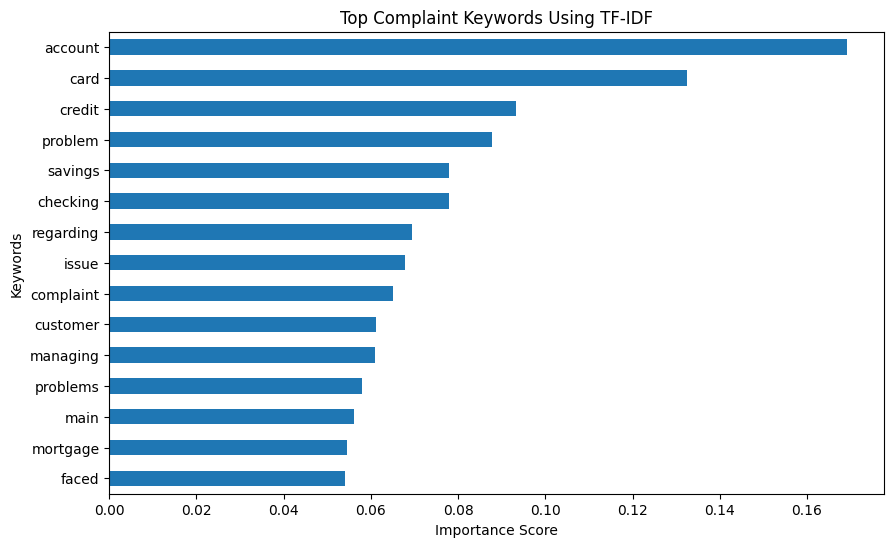

In [120]:
plt.figure(figsize=(10,6))

top_words.sort_values().plot(kind='barh')

plt.title("Top Complaint Keywords Using TF-IDF")
plt.xlabel("Importance Score")
plt.ylabel("Keywords")

plt.show()

# Create word cloud

In [121]:
from wordcloud import WordCloud

In [122]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(' '.join(df['cleaned_text']))

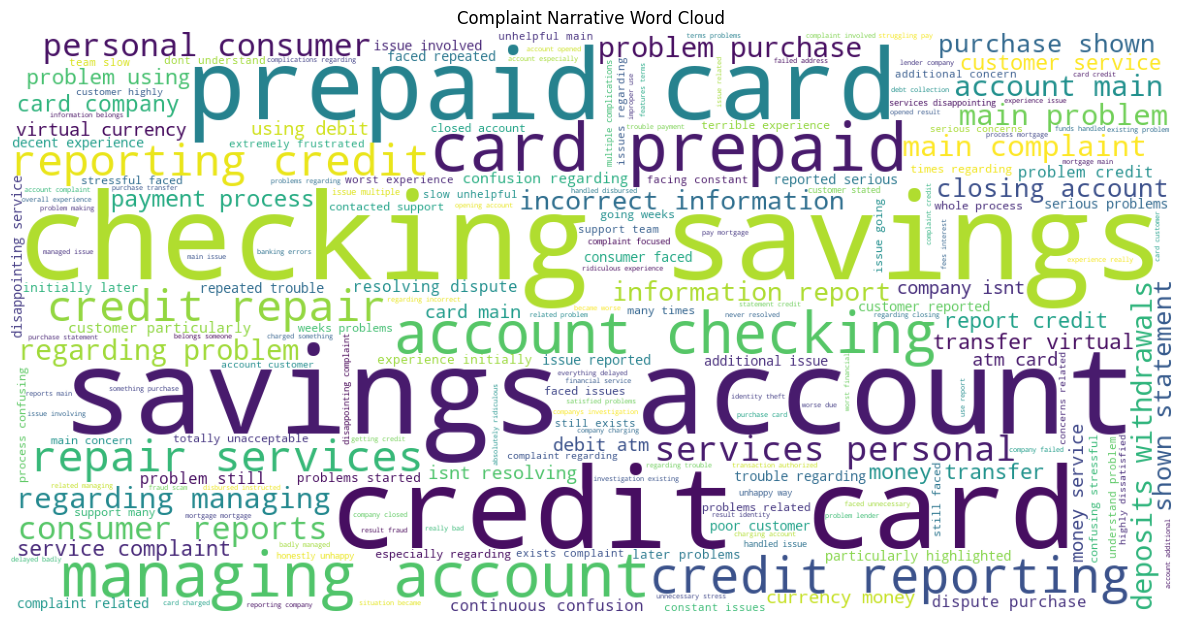

In [123]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Complaint Narrative Word Cloud")

plt.show()

## Product-Specific Complaint Intelligence

In [124]:
mortgage_df = df[
    df['product'].str.contains('mortgage', na=False)
]

In [125]:
mortgage_text = ' '.join(mortgage_df['cleaned_text'])

## Create Product-Wise Complaint Themes

In [126]:
df.groupby('product').size().sort_values(ascending=False).head(10)

product
checking or savings account                                                     24814
credit card or prepaid card                                                     16197
credit reporting, credit repair services, or other personal consumer reports     7710
mortgage                                                                         6601
money transfer, virtual currency, or money service                               3453
debt collection                                                                  2736
vehicle loan or lease                                                             633
payday loan, title loan, or personal loan                                         333
student loan                                                                       39
dtype: int64

## Product-Wise Complaint Intelligence

In [127]:
df['product'].value_counts().head(10)

product
checking or savings account                                                     24814
credit card or prepaid card                                                     16197
credit reporting, credit repair services, or other personal consumer reports     7710
mortgage                                                                         6601
money transfer, virtual currency, or money service                               3453
debt collection                                                                  2736
vehicle loan or lease                                                             633
payday loan, title loan, or personal loan                                         333
student loan                                                                       39
Name: count, dtype: int64

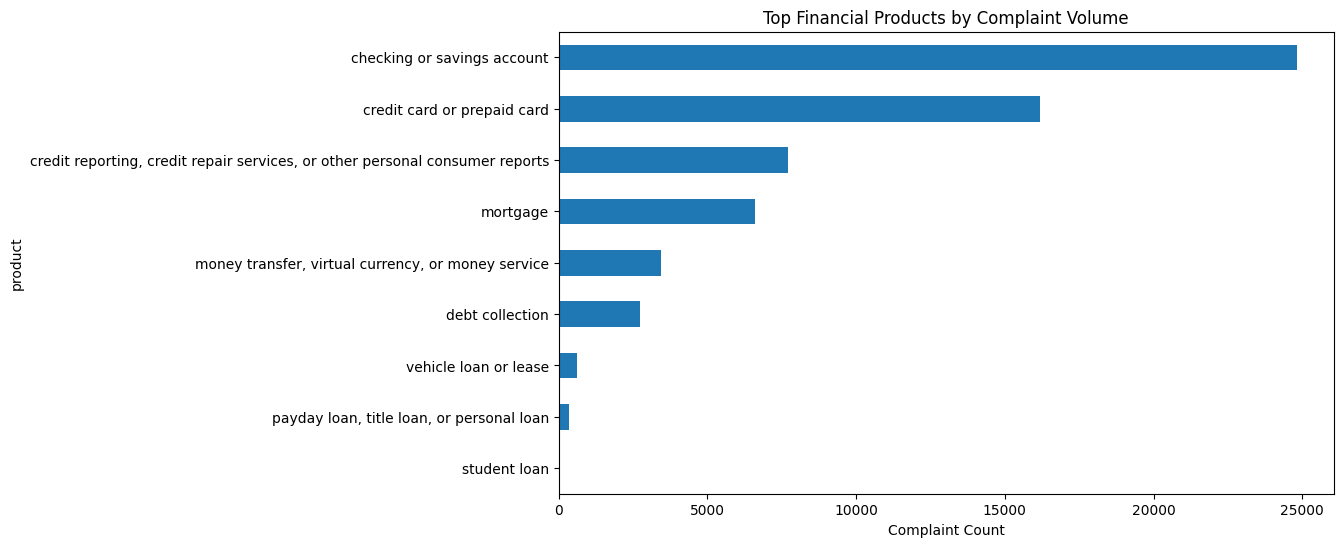

In [128]:
top_products = df['product'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title("Top Financial Products by Complaint Volume")
plt.xlabel("Complaint Count")

plt.show()

## Delayed Response Intelligence

In [129]:
delay_analysis = df.groupby('product')['response_days'] \
                   .mean() \
                   .sort_values(ascending=False)

In [130]:
delay_analysis.head(10)

product
student loan                                                                    2.128205
mortgage                                                                        1.860779
payday loan, title loan, or personal loan                                       1.675676
debt collection                                                                 1.643275
vehicle loan or lease                                                           1.440758
checking or savings account                                                     1.233296
credit card or prepaid card                                                     1.127369
money transfer, virtual currency, or money service                              1.064002
credit reporting, credit repair services, or other personal consumer reports    0.740078
Name: response_days, dtype: float64

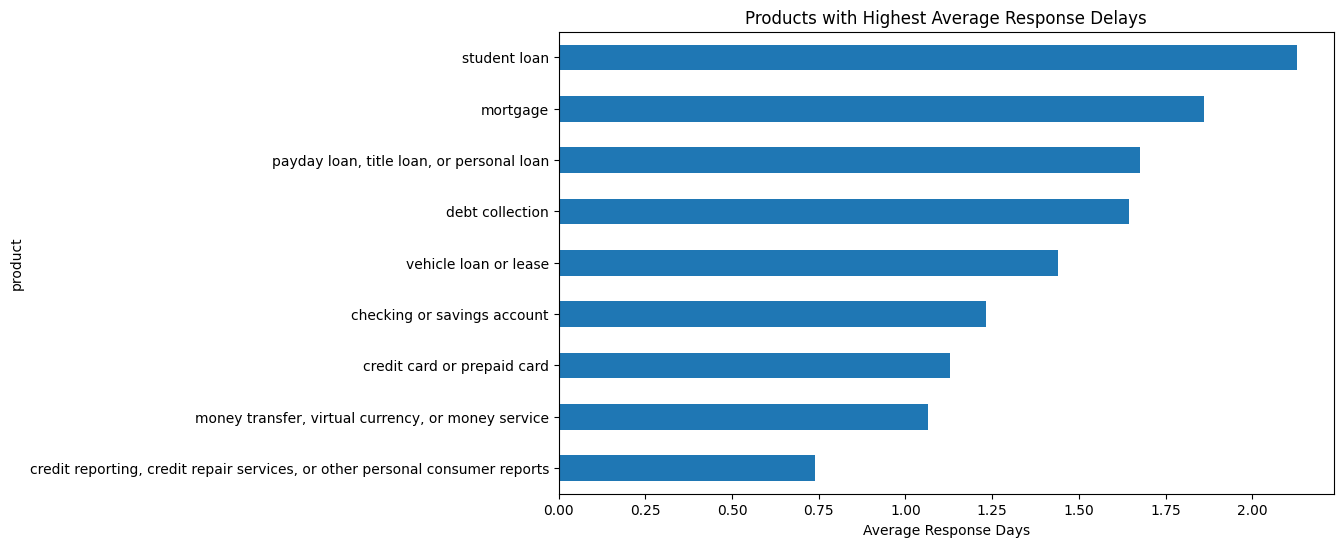

In [131]:
plt.figure(figsize=(10,6))

delay_analysis.head(10).sort_values().plot(kind='barh')

plt.title("Products with Highest Average Response Delays")
plt.xlabel("Average Response Days")

plt.show()

## Complaint Trends Over Time

In [132]:
monthly_complaints = df.groupby('submission_month').size()

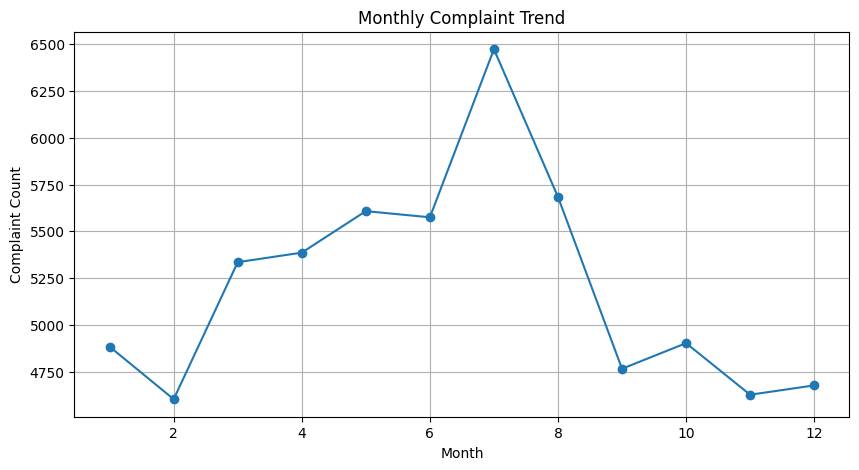

In [133]:
plt.figure(figsize=(10,5))

monthly_complaints.plot(marker='o')

plt.title("Monthly Complaint Trend")
plt.xlabel("Month")
plt.ylabel("Complaint Count")

plt.grid(True)

plt.show()

## State-Level Complaint Analysis

In [134]:
top_states = df['state'].value_counts().head(10)

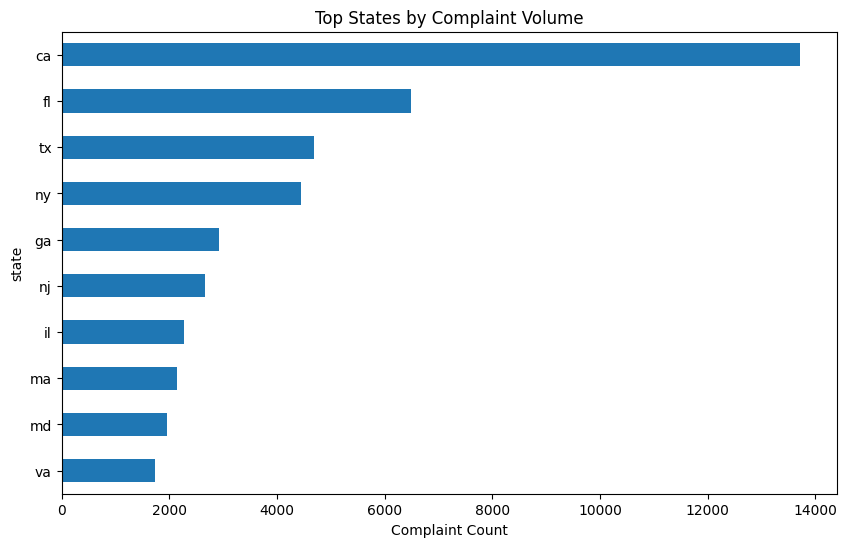

In [135]:
plt.figure(figsize=(10,6))

top_states.sort_values().plot(kind='barh')

plt.title("Top States by Complaint Volume")
plt.xlabel("Complaint Count")

plt.show()

## Complaint channel analysis

In [136]:
channel_analysis = df['submitted_via'].value_counts()

## Create Complaint Year-Month Feature

In [137]:
df['year_month'] = df['date_submitted'].dt.to_period('M')

In [138]:
df['year_month'] = df['year_month'].astype(str)

## Create Complaint Quarter

In [139]:
df['submission_quarter'] = df['date_submitted'].dt.quarter

## Create Response Speed Categories

In [140]:
def response_speed(days):

    if days <= 1:
        return 'fast'

    elif days <= 7:
        return 'moderate'

    else:
        return 'delayed'

In [141]:
df['response_speed_category'] = df['response_days'].apply(response_speed)

# create complaint severity categories

In [142]:
def severity_category(days):

    if days <= 2:
        return 'low'

    elif days <= 7:
        return 'medium'

    else:
        return 'high'

In [143]:
df['severity_level'] = df['response_days'].apply(severity_category)

# product complaint volume category

In [144]:
product_counts = df['product'].value_counts()

In [145]:
def product_volume_category(product):

    count = product_counts[product]

    if count > 1000:
        return 'high_volume'

    elif count > 300:
        return 'medium_volume'

    else:
        return 'low_volume'

In [146]:
df['product_volume_category'] = df['product'].apply(product_volume_category)

# Create timely response binary feature

In [147]:
df['timely_binary'] = df['timely_response'].map({
    'yes': 1,
    'no': 0
})

# Create narrative length feature

In [148]:
df['narrative_length'] = df['complaint_narrative'].apply(len)

# Create word count feature

In [149]:
df['word_count'] = df['cleaned_text'].apply(
    lambda x: len(x.split())
)

# Create complaint intensity score

In [150]:
df['complaint_intensity_score'] = (
    df['response_days'] +
    df['word_count']
)

# Create top product flag

In [151]:
top_5_products = df['product'].value_counts().head(5).index

In [152]:
df['top_product_flag'] = df['product'].isin(top_5_products)

# Create complaint frequency table

In [153]:
complaint_summary = df.groupby('product').agg({

    'complaint_id': 'count',
    'response_days': 'mean',
    'timely_binary': 'mean',
    'complaint_intensity_score': 'mean'

}).reset_index()

In [154]:
complaint_summary.columns = [
    'product',
    'total_complaints',
    'avg_response_days',
    'timely_response_rate',
    'avg_intensity_score'
]

In [155]:
df.to_csv(
    '/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2/dashboard_ready_dataset.csv',
    index=False
)

In [156]:
complaint_summary.to_csv(
    '/Users/anshikapandey/Library/Mobile Documents/com~apple~CloudDocs/DA/project_2/complaint_summary.csv',
    index=False
)